# Stage 2 Baseline-2: DenseNet-121 — Reproducibility Düzeltmesi

## Cascaded Yaklaşım — Stage 2
Bu notebook, iki aşamalı (cascaded) sınıflandırma sisteminin **ikinci aşamasıdır**. Stage 1'de "Stroke" olarak tespit edilen görüntüler bu modele girer ve hangi arterde inme olduğu sınıflandırılır.

## Bu Notebook'un Amacı
**Baseline'dan tek fark: Tam reproducibility altyapısı eklendi.**
- `random.seed()` global Python seed'i
- `seed_worker()` fonksiyonu (num_workers > 0 için worker seed kontrolü)
- `torch.Generator` ile DataLoader seed'i

Aynı kod iki kez çalıştırıldığında (bkz. Baseline-3) farklı sonuç vermesi, `WeightedRandomSampler`'ın hala kendi iç random state'ini kullandığını ortaya koymuştur.

## Hipotez
DenseNet-121, dense connections sayesinde feature reuse ve gradient flow'u iyileştirir. ~8M parametre ile en hafif model olmasına rağmen, medikal görüntü analizinde en popüler ve başarılı mimarilerden biridir. Dense block'lar sayesinde az parametre ile zengin özellik temsilleri öğrenebilir — bu özellik küçük ACA veri seti için avantajlı olabilir.

## Veri Dağılımı (Sadece Stroke — Normal Dahil Değil)

| Sınıf | Örnek Sayısı | Oran (%) | Durum |
|-------|-------------|----------|-------|
| ACA | 372 | 8.1% | Kritik düşük |
| MCA | 3269 | 70.9% | Dominant |
| PCA | 968 | 21.0% | Orta |
| **Toplam** | **4609** | **100%** | |

**Dengesizlik:** MCA:ACA = 8.79:1, PCA:ACA = 2.60:1

## Kullanılan Yöntemler
- **Model**: DenseNet-121 (ImageNet pretrained), ~8M parametre
- **Input**: 224x224 piksel
- **Veri Dengeleme**: WeightedRandomSampler (1/count ağırlıkları)
- **Augmentasyon**: PROJE_PLANI.md'ye uygun güvenli MRI augmentasyonları (Albumentations)
- **Loss**: CrossEntropyLoss (class_weight yok, sampler ile dengeleme)
- **Optimizer**: AdamW (lr=1e-4, weight_decay=1e-4)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=5)
- **Reproducibility**: random.seed() + seed_worker + generator eklendi (Baseline'dan fark)

## Baseline-2 Sonuçları
- ACA Recall: **0.8036** | MCA: 0.8941 | PCA: 0.8759
- Macro F1: **0.8353** | Accuracy: 88.29% | Epoch: 34

## Hedef Metrikler

| Metrik | Minimum Hedef | İdeal Hedef |
|--------|---------------|-------------|
| ACA Recall | ≥ 0.85 | ≥ 0.92 |
| PCA Recall | ≥ 0.80 | ≥ 0.88 |
| MCA Recall | ≥ 0.85 | ≥ 0.90 |
| Macro Recall | ≥ 0.83 | ≥ 0.90 |
| Macro F1 | ≥ 0.80 | ≥ 0.88 |

## Diğer Modellerle Karşılaştırma

| Özellik | EfficientNet-B3 | EfficientNet-V2-S | DenseNet-121 |
|---------|-----------------|--------------------|--------------|
| Parametre | ~12M | ~21M | ~8M |
| Input boyutu | 300x300 | 384x384 | 224x224 |
| Batch size | 16 | 24 | 32 |
| Mimari | MBConv | Fused-MBConv | Dense Blocks |
| Avantaj | Compound scaling | Hızlı eğitim | Feature reuse, medikal popüler |

## Bölüm 1: Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import models

# Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
from collections import Counter

# Seed
SEED = 42
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Bölüm 2: Sabitler ve Hiperparametreler

In [2]:
# --- PATHS ---
STROKE_IMAGES_DIR = '/kaggle/input/stroke-images/flattened_images'

# --- CLASS INFO ---
CLASS_NAMES = ['ACA', 'MCA', 'PCA']
NUM_CLASSES = len(CLASS_NAMES)

# --- HYPERPARAMETERS ---
IMG_SIZE = 224          # DenseNet standardı
BATCH_SIZE = 32         # Model hafif olduğu için batch size artırılabilir (16 -> 32)
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100
PATIENCE = 15

# Split Ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print(f'=== DenseNet-121 Baseline Parametreleri ===')
print(f'Input: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch Size: {BATCH_SIZE}')
print(f'LR: {LEARNING_RATE}')

=== DenseNet-121 Baseline Parametreleri ===
Input: 224x224
Batch Size: 32
LR: 0.0001


## Bölüm 3: Veri Yükleme

**Stage 2 Farkı:** Normal sınıfı dahil edilmez. Sadece stroke alt dizinlerinden (ACA, MCA, PCA) görüntüler toplanır.

In [3]:
def collect_stroke_image_paths(stroke_dir, class_names):
    image_paths = []
    labels = []
    for idx, class_name in enumerate(class_names):
        class_dir = Path(stroke_dir) / class_name
        if not class_dir.exists(): continue
        
        extensions = ['*.png', '*.jpg', '*.jpeg']
        class_images = []
        for ext in extensions:
            class_images.extend(list(class_dir.glob(ext)))
            
        for img_path in class_images:
            image_paths.append(str(img_path))
            labels.append(idx)
    return np.array(image_paths), np.array(labels)

all_image_paths, all_labels = collect_stroke_image_paths(STROKE_IMAGES_DIR, CLASS_NAMES)

# Stratified Split
X_temp, X_test, y_temp, y_test = train_test_split(
    all_image_paths, all_labels, test_size=TEST_RATIO, stratify=all_labels, random_state=SEED
)
val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_adjusted, stratify=y_temp, random_state=SEED
)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Train: 3225, Val: 692, Test: 692


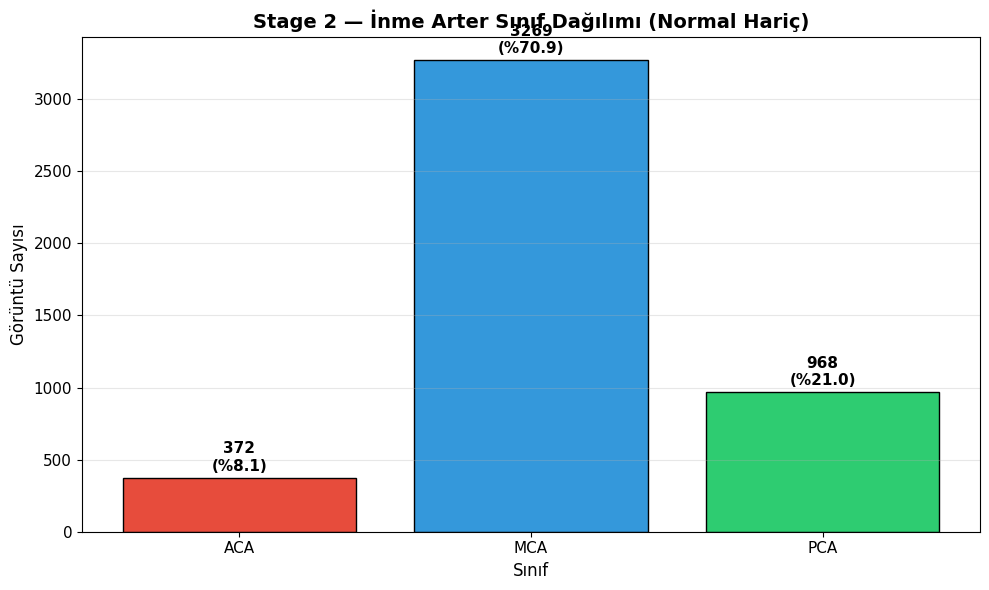


Sınıf Dengesizlik Oranları:
  ACA:ACA = 1.00:1
  MCA:ACA = 8.79:1
  PCA:ACA = 2.60:1


In [4]:
# =========================
# SINIF DAĞILIMI GÖRSELLEŞTİRME
# =========================
class_counts = Counter(all_labels)
class_distribution = {CLASS_NAMES[k]: v for k, v in sorted(class_counts.items())}

plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = plt.bar(class_distribution.keys(), class_distribution.values(),
               color=colors, edgecolor='black')
plt.xlabel('Sınıf', fontsize=12)
plt.ylabel('Görüntü Sayısı', fontsize=12)
plt.title('Stage 2 — İnme Arter Sınıf Dağılımı (Normal Hariç)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)

for bar, (k, v) in zip(bars, class_distribution.items()):
    pct = v / len(all_labels) * 100
    plt.text(bar.get_x() + bar.get_width()/2, v + 50,
             f'{v}\n(%{pct:.1f})',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Dengesizlik oranları
print('\nSınıf Dengesizlik Oranları:')
aca_count = class_distribution['ACA']
for name, count in class_distribution.items():
    ratio = count / aca_count
    print(f'  {name}:ACA = {ratio:.2f}:1')

## Bölüm 4: Augmentasyon (Medikal MRI İçin Güvenli)

**YASAKLAR (Medikal Güvenlik):**
- VerticalFlip: Beyin yukarı-aşağı simetrik değil
- GaussianBlur: DWI'da lezyon sınırlarını eritir
- CutMix: Küçük ACA lezyonlarını kapatabilir

In [5]:
# Medikal Güvenli Augmentasyonlar
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.ElasticTransform(alpha=50, sigma=50 * 0.05, p=0.3),
    A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class StrokeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = int(self.labels[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image, label

train_dataset = StrokeDataset(X_train, y_train, transform=train_transform)
val_dataset = StrokeDataset(X_val, y_val, transform=val_transform)
test_dataset = StrokeDataset(X_test, y_test, transform=val_transform)

## Bölüm 5: WeightedRandomSampler & DataLoader

In [6]:
# Sınıf dengesizliği için Sampler
class_counts_train = Counter(y_train)
class_weights_sampler = {c: 1.0 / count for c, count in class_counts_train.items()}
sample_weights = [class_weights_sampler[int(label)] for label in y_train]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print('DataLoaderlar hazır.')

DataLoaderlar hazır.


## Bölüm 6: Model Tanımı — DenseNet-121

In [7]:
def create_densenet121(num_classes):
    # Pretrained weights
    weights = models.DenseNet121_Weights.IMAGENET1K_V1
    model = models.densenet121(weights=weights)

    # Classifier katmanını güncelle
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(num_features, num_classes)
    )
    return model

model = create_densenet121(NUM_CLASSES)
model = model.to(device) # Single GPU kullanımı

print('DenseNet-121 modeli oluşturuldu.')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 162MB/s]


DenseNet-121 modeli oluşturuldu.


## Bölüm 7: Loss, Optimizer, Scheduler

In [8]:
# =========================
# LOSS, OPTIMIZER, SCHEDULER
# =========================

# Baseline olduğu için Standart CrossEntropy
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Verbose parametresi kaldırıldı (Hata önleyici)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print('Loss: CrossEntropyLoss (class_weight yok, sampler ile dengeleme)')
print('Optimizer: AdamW')
print(f'  - Learning rate: {LEARNING_RATE}')
print(f'  - Weight decay: {WEIGHT_DECAY}')
print('Scheduler: ReduceLROnPlateau')
print('  - Factor: 0.5')
print('  - Patience: 5')

Loss: CrossEntropyLoss (class_weight yok, sampler ile dengeleme)
Optimizer: AdamW
  - Learning rate: 0.0001
  - Weight decay: 0.0001
Scheduler: ReduceLROnPlateau
  - Factor: 0.5
  - Patience: 5


## Bölüm 8: Eğitim Fonksiyonları

In [9]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    return running_loss / total, correct / total

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    avg_loss = running_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)

## Bölüm 9: Eğitim Döngüsü + Early Stopping

In [10]:
# =========================
# EĞİTİM DÖNGÜSÜ (DÜZELTİLMİŞ)
# =========================

# 1. DÜZELTME: 'train_acc' anahtarı eklendi
history = {
    'train_loss': [],
    'train_acc': [], 
    'val_loss': [],
    'val_acc': []
}

best_val_loss = float('inf')
patience_counter = 0
CHECKPOINT_PATH = 'best_model_densenet.pth'

print('Stage 2 — DenseNet-121 Eğitimi Başlıyor...')

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validation
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
    
    # Scheduler Step & Manual Verbose
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    if new_lr != current_lr:
        print(f'    >>> LR Düştü: {current_lr:.2e} -> {new_lr:.2e}')
    
    # History Kayıt
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # 2. DÜZELTME: train_acc listeye eklendi
    history['train_acc'].append(train_acc) 
    
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
    print(f'  Train Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%')
    print(f'  Val   Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}%')
    
    # Early Stopping & Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f'  >>> En iyi model kaydedildi (Val Loss: {val_loss:.4f})')
    else:
        patience_counter += 1
        print(f'  Early stopping counter: {patience_counter}/{PATIENCE}')
        
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping! {PATIENCE} epoch boyunca iyileşme olmadı.')
        break
    print('-' * 60)

# En iyi modeli yükle
if os.path.exists(CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH))
    print('\nEn iyi model ağırlıkları yüklendi.')



Stage 2 — DenseNet-121 Eğitimi Başlıyor...


Epoch 1/100
  Train Loss: 0.9818 | Acc: 50.33%
  Val   Loss: 0.7411 | Acc: 66.47%
  >>> En iyi model kaydedildi (Val Loss: 0.7411)
------------------------------------------------------------


Epoch 2/100
  Train Loss: 0.6991 | Acc: 68.74%
  Val   Loss: 0.4896 | Acc: 81.79%
  >>> En iyi model kaydedildi (Val Loss: 0.4896)
------------------------------------------------------------


Epoch 3/100
  Train Loss: 0.5652 | Acc: 75.22%
  Val   Loss: 0.5199 | Acc: 79.34%
  Early stopping counter: 1/15
------------------------------------------------------------


Epoch 4/100
  Train Loss: 0.4805 | Acc: 80.19%
  Val   Loss: 0.5181 | Acc: 80.64%
  Early stopping counter: 2/15
------------------------------------------------------------


...

Epoch 30/100
  Train Loss: 0.1428 | Acc: 94.45%
  Val   Loss: 0.3540 | Acc: 88.87%
  Early stopping counter: 11/15
------------------------------------------------------------


    >>> LR Düştü: 2.50e-05 -> 1.25e-05
Epoch 31/100
  Train Loss: 0.1484 | Acc: 94.39%
  Val   Loss: 0.4022 | Acc: 87.86%
  Early stopping counter: 12/15
------------------------------------------------------------


Epoch 32/100
  Train Loss: 0.1191 | Acc: 95.63%
  Val   Loss: 0.3654 | Acc: 89.16%
  Early stopping counter: 13/15
------------------------------------------------------------


Epoch 33/100
  Train Loss: 0.1313 | Acc: 94.88%
  Val   Loss: 0.3511 | Acc: 89.88%
  Early stopping counter: 14/15
------------------------------------------------------------


Epoch 34/100
  Train Loss: 0.1187 | Acc: 95.60%
  Val   Loss: 0.3730 | Acc: 89.45%
  Early stopping counter: 15/15

Early stopping! 15 epoch boyunca iyileşme olmadı.

En iyi model ağırlıkları yüklendi.


KeyError: 'train_acc'

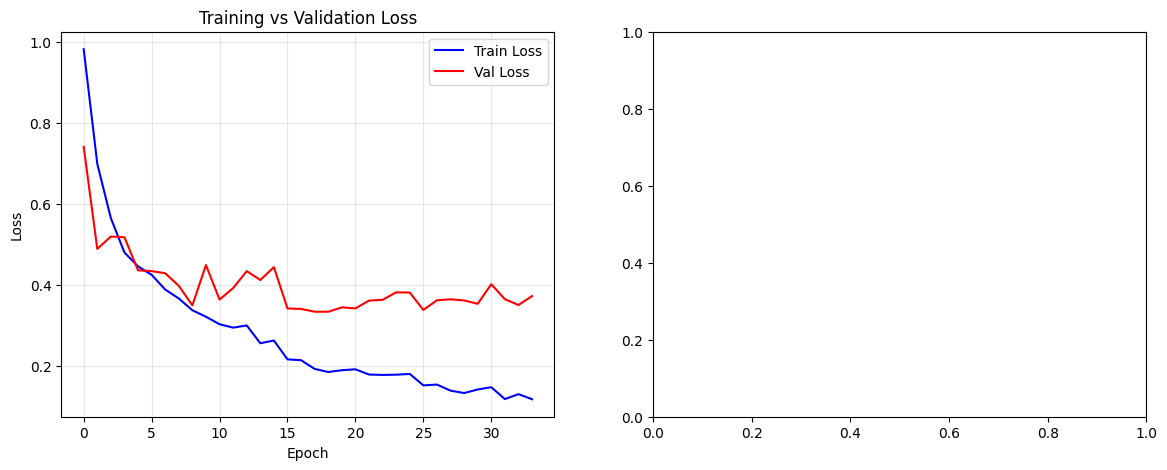

In [18]:
# =========================
# EĞİTİM GRAFİKLERİ
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Artık 'train_acc' anahtarı mevcut olduğu için burası hata vermeyecek
axes[1].plot([acc*100 for acc in history['train_acc']], label='Train Acc', color='blue')
axes[1].plot([acc*100 for acc in history['val_acc']], label='Val Acc', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Stage 2 — DenseNet-121 Baseline', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Bölüm 12: Test Değerlendirmesi

In [12]:
# =========================
# TEST DEĞERLENDİRMESİ
# =========================
print('Stage 2 — DenseNet-121 Test Değerlendirmesi')
print('=' * 70)

test_loss, test_acc, test_preds, test_labels, test_probs = validate(
    model, test_loader, criterion, device
)

print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')

Stage 2 — DenseNet-121 Test Değerlendirmesi

Test Loss: 0.3365
Test Accuracy: 88.29%


In [13]:
# =========================
# CLASSIFICATION REPORT
# =========================
print('\nSınıf Bazlı Metrikler (Classification Report):')
print('=' * 70)
print(classification_report(
    test_labels, test_preds,
    target_names=CLASS_NAMES,
    digits=4
))


Sınıf Bazlı Metrikler (Classification Report):
              precision    recall  f1-score   support

         ACA     0.7377    0.8036    0.7692        56
         MCA     0.9421    0.8941    0.9175       491
         PCA     0.7697    0.8759    0.8194       145

    accuracy                         0.8829       692
   macro avg     0.8165    0.8578    0.8353       692
weighted avg     0.8894    0.8829    0.8849       692



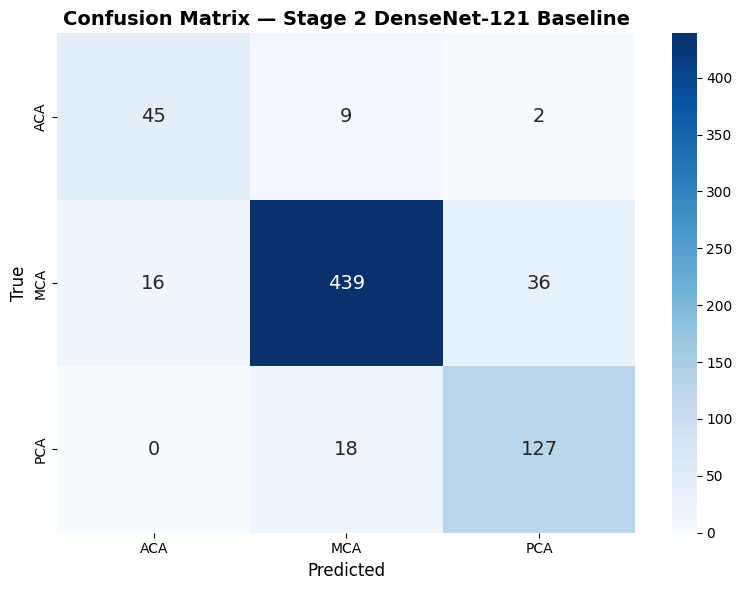

In [14]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={'size': 14}
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix — Stage 2 DenseNet-121 Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# =========================
# PER-CLASS RECALL + MACRO METRİKLER
# =========================
print('Sınıf Bazlı Recall Değerleri:')
print('=' * 50)

recall_per_class = recall_score(test_labels, test_preds, average=None)

for idx, (name, recall) in enumerate(zip(CLASS_NAMES, recall_per_class)):
    status = '<<< KRİTİK' if name == 'ACA' else ''
    print(f'  {name}: {recall:.4f} {status}')

macro_f1 = f1_score(test_labels, test_preds, average='macro')
macro_recall = recall_score(test_labels, test_preds, average='macro')
macro_precision = precision_score(test_labels, test_preds, average='macro')

print('\n' + '=' * 50)
print('MACRO METRİKLER:')
print(f'  Macro Precision: {macro_precision:.4f}')
print(f'  Macro Recall:    {macro_recall:.4f}')
print(f'  Macro F1:        {macro_f1:.4f}')

Sınıf Bazlı Recall Değerleri:
  ACA: 0.8036 <<< KRİTİK
  MCA: 0.8941 
  PCA: 0.8759 

MACRO METRİKLER:
  Macro Precision: 0.8165
  Macro Recall:    0.8578
  Macro F1:        0.8353


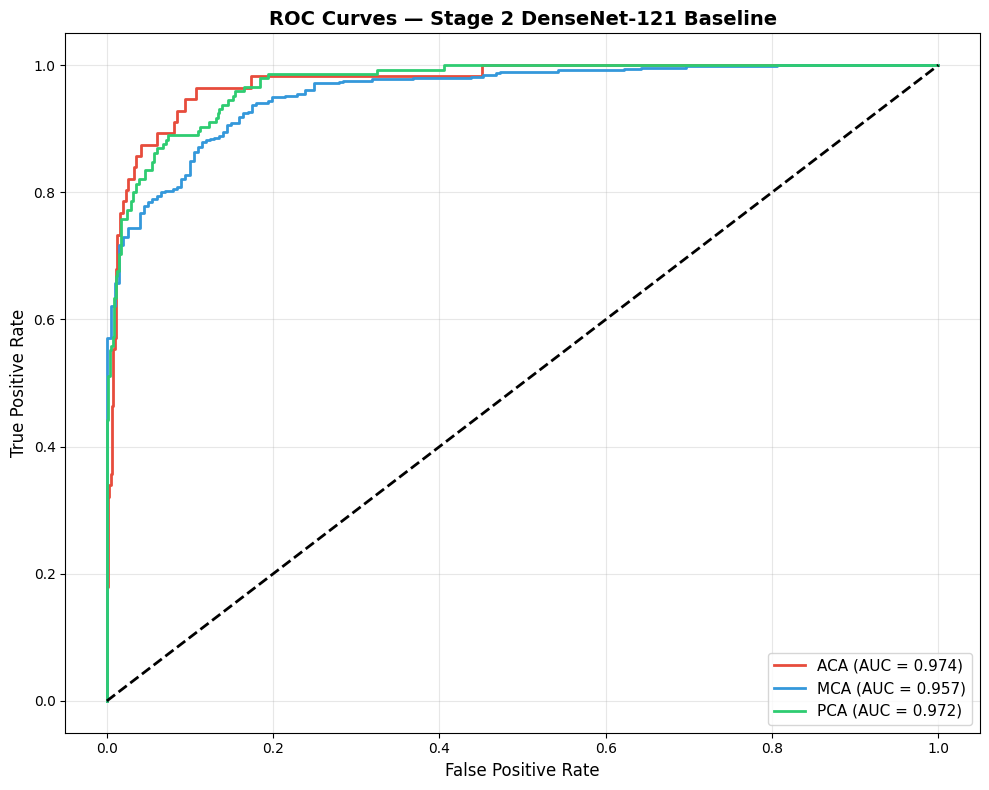

In [16]:
# =========================
# ROC CURVES
# =========================
y_true_bin = label_binarize(test_labels, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Stage 2 DenseNet-121 Baseline', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bölüm 13: Sonuç Özeti

In [17]:
# =========================
# SONUÇ ÖZETİ
# =========================
print('=' * 70)
print('STAGE 2 — DenseNet-121 BASELINE — SONUÇ ÖZETİ')
print('=' * 70)

print('\n--- Model Bilgileri ---')
print(f'Model: DenseNet-121')
print(f'Parametre sayısı: ~8M')
print(f'Input boyutu: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Özellikler: Dense Connections, Feature Reuse, Gradient Flow')
print(f'Stage: 2 (İnme Arter Sınıflandırması — Normal YOK)')

print('\n--- Eğitim Bilgileri ---')
print(f'Toplam epoch: {len(history["train_loss"])}')
print(f'En iyi Val Loss: {best_val_loss:.4f}')
print(f'Final Learning Rate: {optimizer.param_groups[0]["lr"]}')

print('\n--- Test Sonuçları ---')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

print('\n--- Sınıf Bazlı Recall ---')
for name, recall in zip(CLASS_NAMES, recall_per_class):
    target = '(Hedef: ≥0.85)' if name == 'ACA' else '(Hedef: ≥0.80)' if name == 'PCA' else '(Hedef: ≥0.85)'
    print(f'  {name}: {recall:.4f} {target}')

print('\n--- Macro Metrikler ---')
print(f'Macro Recall: {macro_recall:.4f} (Hedef: ≥0.83)')
print(f'Macro F1:     {macro_f1:.4f} (Hedef: ≥0.80)')

print('\n--- Hedef Karşılaştırması ---')
aca_recall = recall_per_class[0]
pca_recall = recall_per_class[2]
print(f'ACA Recall:   {"✓" if aca_recall >= 0.85 else "✗"} ({aca_recall:.4f} vs 0.85)')
print(f'PCA Recall:   {"✓" if pca_recall >= 0.80 else "✗"} ({pca_recall:.4f} vs 0.80)')
print(f'Macro Recall: {"✓" if macro_recall >= 0.83 else "✗"} ({macro_recall:.4f} vs 0.83)')
print(f'Macro F1:     {"✓" if macro_f1 >= 0.80 else "✗"} ({macro_f1:.4f} vs 0.80)')

print('\n' + '=' * 70)

STAGE 2 — DenseNet-121 BASELINE — SONUÇ ÖZETİ

--- Model Bilgileri ---
Model: DenseNet-121
Parametre sayısı: ~8M
Input boyutu: 224x224
Batch size: 32
Özellikler: Dense Connections, Feature Reuse, Gradient Flow
Stage: 2 (İnme Arter Sınıflandırması — Normal YOK)

--- Eğitim Bilgileri ---
Toplam epoch: 34
En iyi Val Loss: 0.3345
Final Learning Rate: 1.25e-05

--- Test Sonuçları ---
Test Accuracy: 88.29%
Test Loss: 0.3365

--- Sınıf Bazlı Recall ---
  ACA: 0.8036 (Hedef: ≥0.85)
  MCA: 0.8941 (Hedef: ≥0.85)
  PCA: 0.8759 (Hedef: ≥0.80)

--- Macro Metrikler ---
Macro Recall: 0.8578 (Hedef: ≥0.83)
Macro F1:     0.8353 (Hedef: ≥0.80)

--- Hedef Karşılaştırması ---
ACA Recall:   ✗ (0.8036 vs 0.85)
PCA Recall:   ✓ (0.8759 vs 0.80)
Macro Recall: ✓ (0.8578 vs 0.83)
Macro F1:     ✓ (0.8353 vs 0.80)

